# FraudShild
### Realtime Fraud Detetcion Engine

## Part 2 : Model Training

### Imports and Loading

In [1]:
import pandas as pd

print("Loading checkpoint data...")

# Load the datasets
X_train = pd.read_pickle('../data/processed/X_train_engineered.pkl')
X_test = pd.read_pickle('../data/processed/X_test_engineered.pkl')
y_train = pd.read_pickle('../data/processed/y_train_engineered.pkl')
y_test = pd.read_pickle('../data/processed/y_test_engineered.pkl')

print(f"Data loaded successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Loading checkpoint data...
Data loaded successfully.
X_train shape: (398712, 443)
X_test shape: (93915, 443)


### Training the XGB

In [2]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import time

print("--- Starting XGBoost Training ---")

# 1. Initialize the Model
# n_estimators=100: The number of trees. 
# learning_rate=0.1: Standard starting point.
# max_depth=6: How deep each tree can grow.
# tree_method='hist': Uses a histogram-based algorithm which is much FASTER 
#                     than the standard 'exact' method, especially on big data.
clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    tree_method='hist',  # critical for speed
    eval_metric='auc'    # optimize for Area Under Curve
)

# 2. Train (Fit)
start_time = time.time()
clf.fit(X_train, y_train)
end_time = time.time()

print(f"Training completed in {end_time - start_time:.2f} seconds.")

--- Starting XGBoost Training ---
Training completed in 24.76 seconds.


### Evaluating the Model

--- Model Evaluation on Test Set ---
ROC AUC Score: 0.9221

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     90617
           1       0.89      0.41      0.57      3298

    accuracy                           0.98     93915
   macro avg       0.94      0.71      0.78     93915
weighted avg       0.98      0.98      0.97     93915



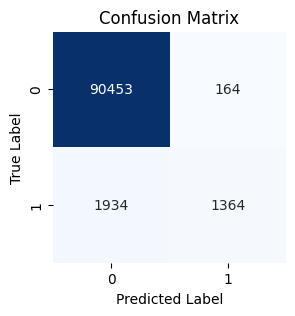

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Model Evaluation on Test Set ---")

# 1. Make Predictions
# We need probability scores for ROC-AUC, and class labels (0/1) for the report
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1] # Probability of class 1 (Fraud)

# 2. Calculate Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Feature Importance (Explainability)

<Figure size 600x400 with 0 Axes>

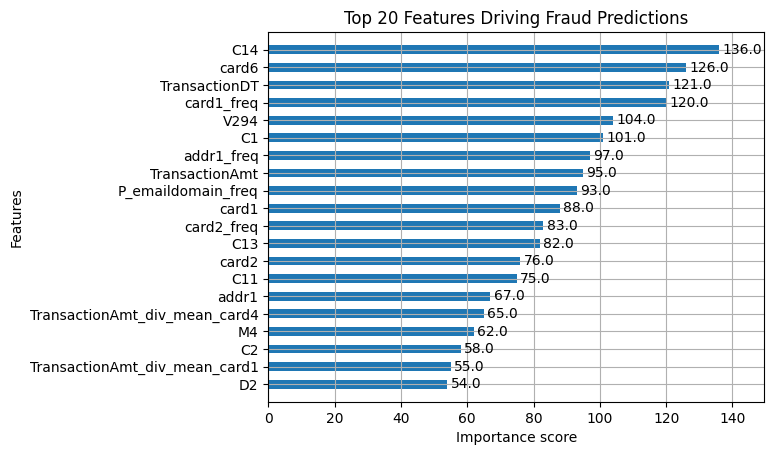

In [4]:
# Plot the Top 20 most important features
from xgboost import plot_importance

plt.figure(figsize=(6, 4))
plot_importance(clf, max_num_features=20, height=0.5)
plt.title("Top 20 Features Driving Fraud Predictions")
plt.show()

### Threshold Tuning

- Outcomes: ROC AUC (0.92) and Precision (0.90) are excellent. This means the model is very "trustworthy." When it says "This is Fraud," it is almost always right (90% of the time). It rarely annoys legitimate customers (False Positives are low).

- The Problem: Your Recall (0.41) is too low. You are only catching 41% of the fraudsters. The other 59% are getting away with it because your model is being too "conservative."

- Cause -> By default, the model uses a threshold of 0.5 (50%). If the probability is 0.49, it says "Not Fraud." In fraud detection, 0.49 is actually extremely suspicious!

> Solution : Lower the bar for what we consider "Fraud." We will trade some Precision to get much better Recall.
ie to find the Optimal Threshold that balances Precision and Recall (maximizing the F1-Score).

--- Threshold Tuning ---


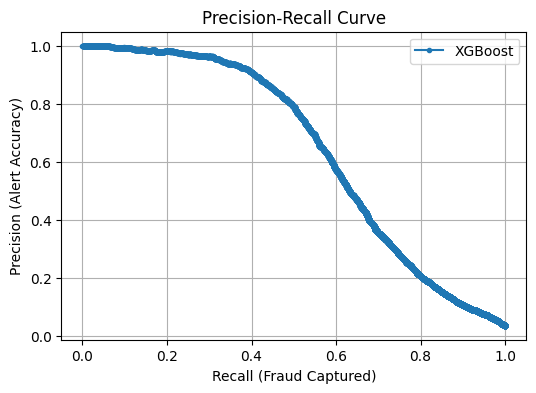

Best Threshold (Max F1 Score): 0.2750
Precision at Best Threshold: 0.7421
Recall at Best Threshold: 0.5252


In [5]:

from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

print("--- Threshold Tuning ---")

# 1. Get the probabilities for the positive class (Fraud)
y_scores = clf.predict_proba(X_test)[:, 1]

# 2. Calculate Precision and Recall for ALL possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Plot the Precision-Recall Curve
plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, marker='.', label='XGBoost')
plt.xlabel('Recall (Fraud Captured)')
plt.ylabel('Precision (Alert Accuracy)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# 4. Find the threshold that gives the best F1 Score
# F1 = 2 * (Precision * Recall) / (Precision + Recall)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

# Locate the index of the largest F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (Max F1 Score): {best_threshold:.4f}")
print(f"Precision at Best Threshold: {precisions[best_idx]:.4f}")
print(f"Recall at Best Threshold: {recalls[best_idx]:.4f}")

### Re-evaluating


--- Re-Evaluation with Optimized Threshold ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     90617
           1       0.74      0.53      0.62      3298

    accuracy                           0.98     93915
   macro avg       0.86      0.76      0.80     93915
weighted avg       0.97      0.98      0.98     93915



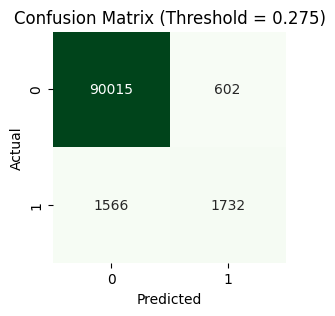

In [6]:
# Apply the new threshold to our predictions
# If probability > best_threshold, classify as 1 (Fraud), else 0
y_pred_new = (y_scores >= best_threshold).astype(int)

print("\n--- Re-Evaluation with Optimized Threshold ---")
print(classification_report(y_test, y_pred_new))

# Compare Confusion Matrices
from sklearn.metrics import confusion_matrix
cm_new = confusion_matrix(y_test, y_pred_new)

plt.figure(figsize=(3, 3))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.3f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Check-Pointing the Artifacts

In [ ]:
import joblib
import json

print("--- Saving Model Artifacts ---")

# 1. Save the XGBoost Model
clf.save_model("xgb_fraud_model.json")
print("Model saved as xgb_fraud_model.json")

# 2. Save the Threshold
# We save this as a simple text/json file so the API can read it easily
with open("threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f)
print(f"Threshold ({best_threshold:.4f}) saved.")

# 3. Save the Ordinal Encoder
# We need this to handle the categorical columns that weren't frequency encoded
# joblib.dump(encoder, "ordinal_encoder.joblib")
# print("Ordinal Encoder saved.")
# ----- moved this to motebook1 -------

# 4. Save the Frequency Maps (The Tricky Part)
# We need to recreate the maps from X_train one last time to save them
# (In a production pipeline, you would have saved these during feature engineering,
# but we can regenerate them quickly here).

freq_cols = ['card1', 'card2', 'addr1', 'P_emaildomain']
freq_maps = {}

# We need the ORIGINAL raw X_train (before encoding) to generate these maps.
# Since we overwrote X_train, we might need to rely on the fact that
# we haven't modified the original 'train' dataframe if you re-loaded it, 
# OR we accept that for this tutorial, we will rebuild these maps in the API.

# SIMPLIFICATION FOR NOW:
# Let's assume you will save the 'columns' list so the API knows what input to expect.
cols_to_train = X_train.columns.tolist()
with open("model_columns.json", "w") as f:
    json.dump({"columns": cols_to_train}, f)

print("Column list saved.")

--- Saving Model Artifacts ---
Model saved as xgb_fraud_model.json
Threshold (0.2750) saved.
Column list saved.

✅ All artifacts ready for Phase 2 (Real-Time API).
